<h1>NAO Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [13]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
ufs_experiments = ['baseline', 'beta.0.1', 'c96_beta.0.1', 'cpc_ics']

In [4]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [5]:
ufs_vars_list = ['phi', 'gh']
era5_var = 'geopotential'
lev=500

In [6]:
era5_data_reader.describe(era5_var)


Variable: geopotential
Dimensions: ('time', 'lat', 'lon', 'lev')
Shape: (92044, 256, 512, 13)
Attributes:
  - long_name: Geopotential
  - short_name: z
  - standard_name: geopotential
  - units: m**2 s**-2


<h5>Define time period</h5>

In [7]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonths = (11,)

<h5>Define NAO locations</h5>

In [8]:
# For PNA, there are 4 reference locations:
region_1 = {'latmin': 20.0, 'lonmin': 200}
region_2 = {'latmin': 45.0, 'lonmin': 195}
region_3 = {'latmin': 55.0, 'lonmin': 245}
region_4 = {'latmin': 30.0, 'lonmin': 275}

<h5>Get the monthly climatology for nino 3.4</h5>

In [9]:
%%capture captured_output
ufs_ds_1 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_1, initmonths=initmonths, lev=lev, flatten=True).load()

ufs_ds_2 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_2, initmonths=initmonths, lev=lev, flatten=True).load()

ufs_ds_3 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_3, initmonths=initmonths, lev=lev, flatten=True).load()

ufs_ds_4 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_4, initmonths=initmonths, lev=lev, flatten=True).load()

<h5>Get the corresponding ERA5 data</h5>

In [10]:
# Loading vertical ERA5 data is inherently inefficient.
# Load all lats and lons into memory first, then split into 4 locations.
all_lats = [this_region['latmin'] for this_region in [region_1, region_2, region_3, region_4]]
all_lons = [this_region['lonmin'] for this_region in [region_1, region_2, region_3, region_4]]

In [11]:
# Find nearest lats and lons
all_lats = [era5_data_reader.dataset().sel(lat=this_lat, method='nearest').lat.values.tolist()
            for this_lat in all_lats]

all_lons = [era5_data_reader.dataset().sel(lon=this_lon, method='nearest').lon.values.tolist()
            for this_lon in all_lons]

In [14]:
# Convert to DataArrays (.sel_points() was deprecated, so this is how we do it now.)
all_lats_da = xr.DataArray(all_lats, dims='lat')
all_lons_da = xr.DataArray(all_lons, dims='lon')

In [15]:
# Sel and Load
era5_ds_1234 = era5_data_reader.dataset().sel(lat=all_lats_da,
                                              lon=all_lons_da,
                                              lev=lev,
                                              time=slice(time_range[0], time_range[1]))[[era5_var]].load()  # load

In [16]:
# Split into localities.
era5_ds_1 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[0]], lon=[all_lons[0]]).load()
era5_ds_2 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[1]], lon=[all_lons[1]]).load()
era5_ds_3 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[2]], lon=[all_lons[2]]).load()
era5_ds_4 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[3]], lon=[all_lons[3]]).load()

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [17]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=True)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=True)
ufs_stats_3 = stats.calc_climatology_anomaly(ufs_ds_3, area_mean=False, use_member_climatology=True)
ufs_stats_4 = stats.calc_climatology_anomaly(ufs_ds_4, area_mean=False, use_member_climatology=True)

In [18]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)
era5_stats_3 = stats.calc_climatology_anomaly(era5_ds_3, area_mean=False)
era5_stats_4 = stats.calc_climatology_anomaly(era5_ds_4, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [19]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_vars_list[0]], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_vars_list[0]], stats=ufs_stats_2)
ufs_da_3 = stats.normalize(da=ufs_ds_3[ufs_vars_list[0]], stats=ufs_stats_3)
ufs_da_4 = stats.normalize(da=ufs_ds_4[ufs_vars_list[0]], stats=ufs_stats_4)

In [20]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)
era5_da_3 = stats.normalize(da=era5_stats_3['monthly_mean'], stats=era5_stats_3)
era5_da_4 = stats.normalize(da=era5_stats_4['monthly_mean'], stats=era5_stats_4)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [21]:
# Index
ufs_pna = 0.25*(ufs_da_1 - ufs_da_2 + ufs_da_3 - ufs_da_4).to_dataset()
era5_pna = 0.25*(era5_da_1 - era5_da_2 + era5_da_3 - era5_da_4).to_dataset()

<h2>Plot SST Index and Anomaly</h2>

Generating 4 panel(s).
Processing years 1994 to 1999


ValueError: zero-size array to reduction operation fmin which has no identity

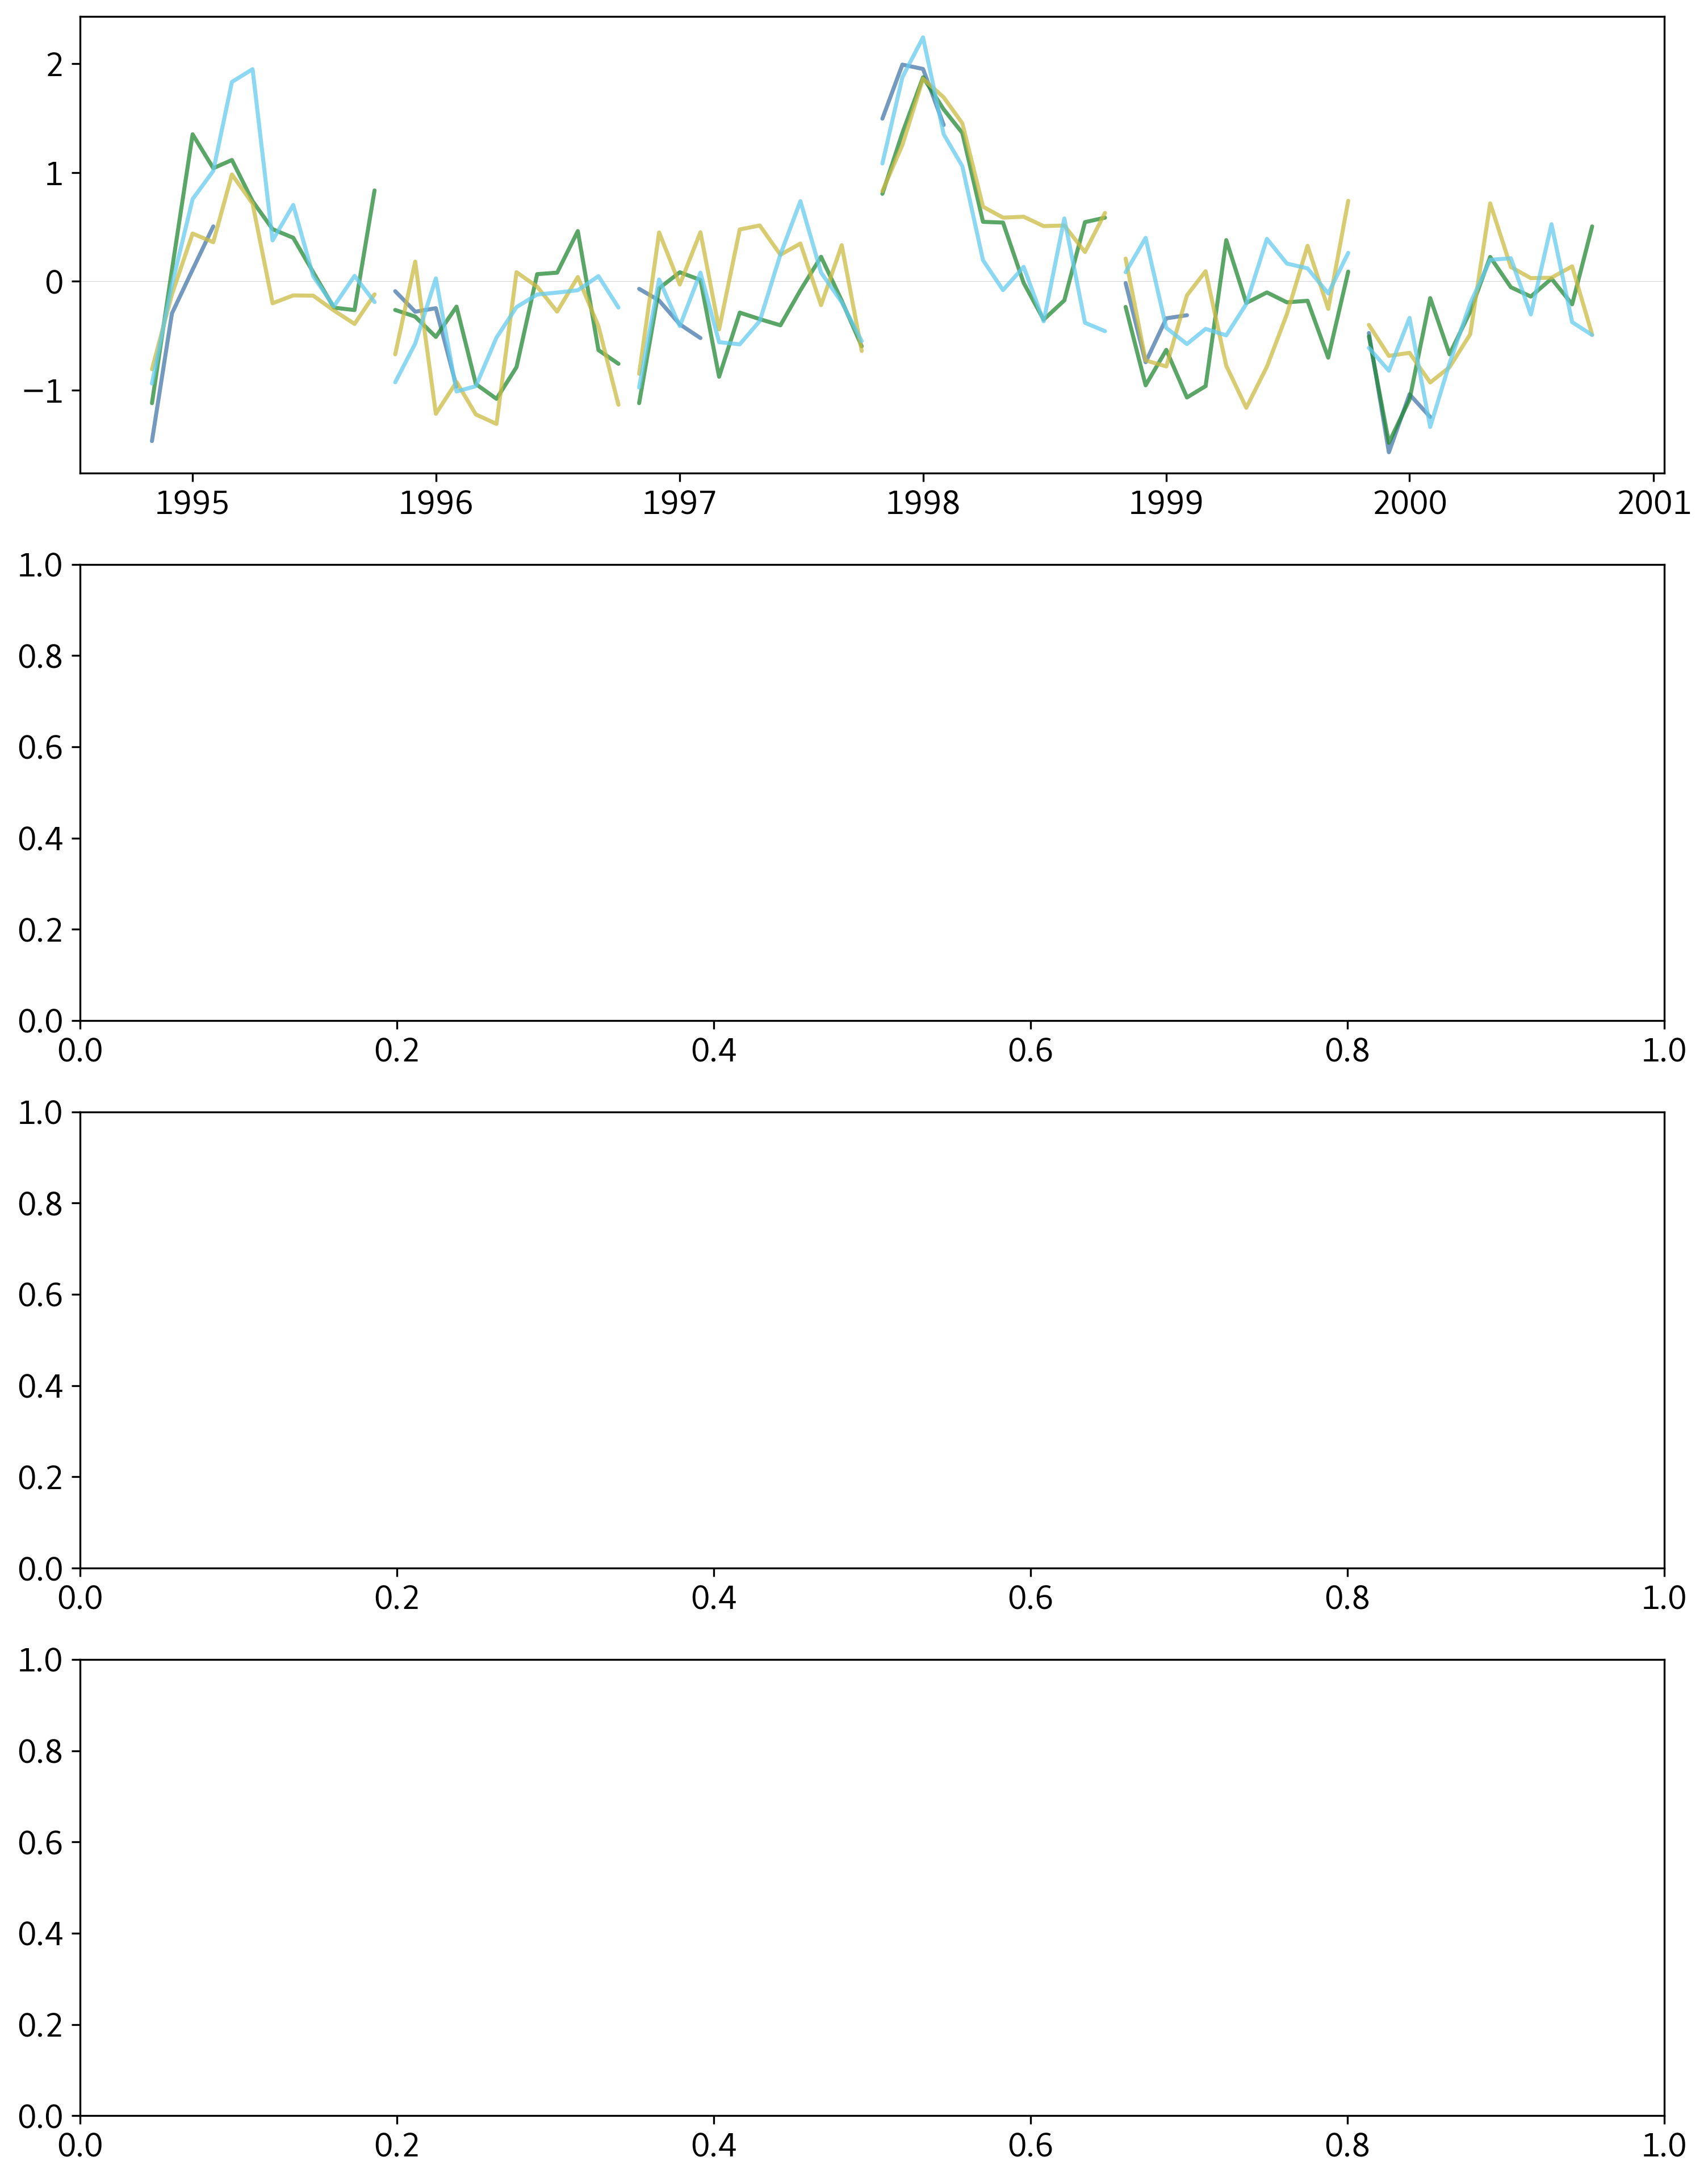

In [27]:
stats.plot_index_spaghetti(ufs_stats={'monthly_mean': ufs_pna[ufs_vars_list[0]]},
                           verif_stats={'monthly_mean': era5_pna[era5_var]},
                           calc_anomaly=False,
                           title=f'PNA Index',
                           verif_label='ERA5',
                           dpi=300)